# Capstone Project 2

**Dataset:** Supermarket Customers

**Business Problem:** *Produk apa yang sering dibeli bersamaan, dan bagaimana strategi bundling dapat meningkatkan total penjualan serta profitabilitas?*

> **Catatan penting:**
> Dataset ini tidak memiliki detail item per invoice/transaksi, sehingga analisis tidak membaca “produk yang dibeli bersamaan dalam satu transaksi”.
> analisis diarahkan menjadi:
> 1. kategori produk yang paling dominan dibeli pelanggan,
> 2. kategori lain yang juga cenderung dibeli oleh pelanggan yang membeli kategori utama,
> 3. rekomendasi bundling berbasis statistika deskriptif dan perilaku belanja pelanggan.

# 1. Latar Belakang

Dalam bisnis retail, memahami pola belanja pelanggan sangat penting untuk meningkatkan penjualan. 
Salah satu strategi yang umum digunakan adalah **bundling**, yaitu menawarkan dua atau lebih produk dalam satu paket promosi.

Namun, agar bundling efektif, perusahaan perlu mengetahui:
- kategori produk mana yang paling dominan dibeli,
- kategori mana yang memiliki nilai pembelian tinggi,
- serta kategori lain apa yang cenderung ikut dibeli oleh pelanggan yang membeli kategori utama.

Dengan memahami pola tersebut, perusahaan dapat menyusun bundling yang lebih relevan, meningkatkan nilai transaksi, dan mendorong penjualan kategori bernilai tinggi.

# 2. Identifikasi Masalah

Berdasarkan struktur dataset yang tersedia, pertanyaan analisis difokuskan pada pola belanja pelanggan yang dapat mendukung strategi bundling secara realistis.

Pertanyaan yang dijawab dalam analisis ini adalah:

1. Kategori produk apa yang memiliki **rata-rata pengeluaran** tertinggi?
2. Kategori produk apa yang memiliki **total kontribusi penjualan** terbesar?
3. Kategori produk apa yang dibeli oleh **jumlah pelanggan terbanyak**?
4. Pada pelanggan yang membeli kategori utama, kategori lain apa yang juga cenderung dibeli?
5. Bagaimana hasil tersebut dapat diterjemahkan menjadi strategi bundling yang berpotensi meningkatkan penjualan dan nilai transaksi?


# 3. Tujuan Analisis

Tujuan analisis ini adalah:
- mengidentifikasi kategori produk utama berdasarkan rata-rata, median, total, dan frekuensi pembelian,
- mengidentifikasi kecenderungan pembelian kategori lain pada pelanggan yang membeli kategori utama,
- menyampaikan insight yang runut dan dapat membantu keputusan bisnis,
- memberikan rekomendasi bundling yang actionable.

# 4. Import Library


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# 5. Load Data

In [17]:
df = pd.read_csv("Supermarket Customers.csv", sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,"58,138.00",0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,"46,344.00",1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,"71,613.00",0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,"26,646.00",1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,"58,293.00",1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


# 6. Data Understanding

In [18]:
# Mengetahui ukuran dataset
print("Shape data:", df.shape)
print("\nDaftar kolom:")
print(df.columns.tolist())

Shape data: (2240, 29)

Daftar kolom:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


#### **Supermarket Customers Dataset Dictionary**
Orang

* **ID**: Pengidentifikasi unik pelanggan
* **Tahun_Lahir**: Tahun kelahiran pelanggan
* **Pendidikan**: Tingkat pendidikan pelanggan
* **Status_Perkawinan**: Status perkawinan pelanggan
* **Pendapatan**: Pendapatan rumah tangga tahunan pelanggan
* **Kidhome**: Jumlah anak dalam rumah tangga pelanggan
* **Teenhome**: Jumlah remaja dalam rumah tangga pelanggan
* **Dt_Customer**: Tanggal pendaftaran pelanggan dengan perusahaan
* **Recency**: Jumlah hari sejak pembelian terakhir pelanggan
* **Keluhan**: 1 jika pelanggan mengeluh dalam 2 tahun terakhir, 0 jika tidak

Produk

* **MntWines**: Jumlah yang dihabiskan untuk anggur dalam 2 tahun terakhir
* **MntFruits**: Jumlah yang dihabiskan untuk buah-buahan dalam 2 tahun terakhir
* **MntMeatProducts**: Jumlah yang dihabiskan untuk daging dalam 2 tahun terakhir
* **MntFishProducts**: Jumlah yang dihabiskan untuk ikan dalam 2 tahun terakhir tahun
* **MntSweetProducts**: Jumlah yang dihabiskan untuk permen dalam 2 tahun terakhir
* **MntGoldProds**: Jumlah yang dihabiskan untuk emas dalam 2 tahun terakhir

Promosi

* **NumDealsPurchases**: Jumlah pembelian yang dilakukan dengan diskon
* **AcceptedCmp1**: 1 jika pelanggan menerima penawaran di kampanye pertama, 0 jika tidak
* **AcceptedCmp2**: 1 jika pelanggan menerima penawaran di kampanye kedua, 0 jika tidak
* **AcceptedCmp3**: 1 jika pelanggan menerima penawaran di kampanye ketiga, 0 jika tidak
* **AcceptedCmp4**: 1 jika pelanggan menerima penawaran di kampanye keempat, 0 jika tidak
* **AcceptedCmp5**: 1 jika pelanggan menerima penawaran di kampanye kelima, 0 jika tidak
* **Response**: 1 jika pelanggan menerima penawaran di kampanye terakhir, 0 jika tidak

Tempat

* **NumWebPurchases**: Jumlah pembelian yang dilakukan melalui situs web perusahaan
* **NumCatalogPurchases**: Jumlah pembelian yang dilakukan menggunakan katalog
* **NumStorePurchases**: Jumlah pembelian yang dilakukan langsung di toko
* **NumWebVisitsMonth**: Jumlah kunjungan ke situs web perusahaan dalam sebulan terakhir

In [19]:
# Mengetahui info tentang kolom (jumlah kolom, nama kolom, nilai null dan tipe data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [20]:
# melihat deskripsi tiap kolom
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,"2,240.00",NaN,NaN,NaN,"5,592.16","3,246.66",0.00,"2,828.25","5,458.50","8,427.75","11,191.00"
Year_Birth,"2,240.00",NaN,NaN,NaN,"1,968.81",11.98,"1,893.00","1,959.00","1,970.00","1,977.00","1,996.00"
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,"2,216.00",NaN,NaN,NaN,"52,247.25","25,173.08","1,730.00","35,303.00","51,381.50","68,522.00","666,666.00"
Kidhome,"2,240.00",NaN,NaN,NaN,0.44,0.54,0.00,0.00,0.00,1.00,2.00
Teenhome,"2,240.00",NaN,NaN,NaN,0.51,0.54,0.00,0.00,0.00,1.00,2.00
Dt_Customer,2240,663,31-08-2012,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,"2,240.00",NaN,NaN,NaN,49.11,28.96,0.00,24.00,49.00,74.00,99.00
MntWines,"2,240.00",NaN,NaN,NaN,303.94,336.60,0.00,23.75,173.50,504.25,"1,493.00"


### Ringkasan Awal
Dataset berisi data pelanggan supermarket, termasuk informasi demografis, pengeluaran per kategori produk, dan perilaku pembelian.
Kolom yang paling relevan untuk business problem ini adalah:

- **MntWines**
- **MntFruits**
- **MntMeatProducts**
- **MntFishProducts**
- **MntSweetProducts**
- **MntGoldProds**

Keenam kolom tersebut merepresentasikan total pengeluaran pelanggan pada masing-masing kategori produk.

# 7. Data Cleaning

Pada tahap ini data akan dibersihkan dari berbagai masalah seperti missing value, data duplikat, serta nilai yang tidak wajar. Proses ini penting karena kualitas data sangat menentukan hasil analisis; jika data tidak bersih, maka insight yang dihasilkan bisa bias atau bahkan salah. Dengan memastikan data sudah rapi dan valid, analisis selanjutnya dapat dilakukan dengan lebih akurat dan dapat dipercaya.

## 7.1 Pemeriksaan Missing Value


In [21]:
# Menghitung jumlah data kosong (missing value) di setiap kolom, lalu menampilkan hanya kolom yang memiliki missing value,
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_count[missing_count > 0]

Income    24
dtype: int64

**Insight:**
Kolom yang memiliki missing value adalah **Income**. Karena Income akan digunakan untuk segmentasi pelanggan, nilai kosong tidak boleh dibiarkan.
Nilai kosong diisi dengan **median** agar tidak terlalu dipengaruhi oleh pelanggan ber-income sangat tinggi, sehingga hasil segmentasi tetap lebih stabil dan representatif.


## 7.2 Pemeriksaan Duplikat

In [22]:
# Menghitung dan menampilkan jumlah baris data yang duplikat (sama persis) dalam dataset.
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


## 7.3 Perbaikan Format Data dan Penambahan Kolom

In [23]:
# copy data agar proses cleaning lebih aman
df_clean = df.copy()

# ubah format tanggal
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], format='%d-%m-%Y', errors='coerce')

# isi missing value Income dengan median
df_clean['Income'] = df_clean['Income'].fillna(df_clean['Income'].median())

# buat kolom umur
df_clean['Age'] = 2026 - df_clean['Year_Birth']

# buat kolom jumlah anak
df_clean['TotalChildren'] = df_clean['Kidhome'] + df_clean['Teenhome']

df_clean[['Dt_Customer', 'Income', 'Age', 'TotalChildren']].head()

,Dt_Customer,Income,Age,TotalChildren
0,2012-09-04,"58,138.00",69,0
1,2014-03-08,"46,344.00",72,2
2,2013-08-21,"71,613.00",61,0
3,2014-02-10,"26,646.00",42,1
4,2014-01-19,"58,293.00",45,1


## 7.4 Pemeriksaan Outlier


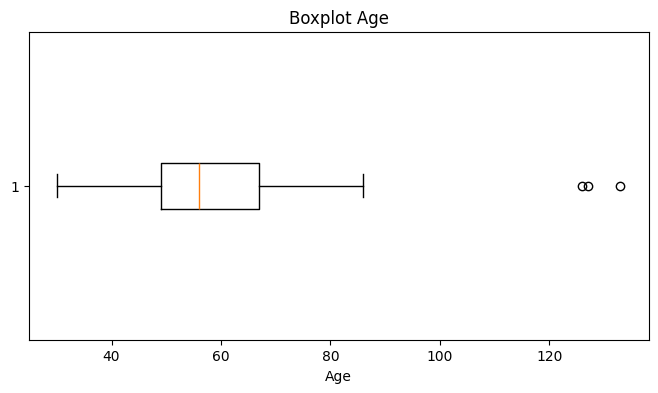

In [24]:
# Menampilkan boxplot dari kolom Age guna melihat distribusi data serta mendeteksi adanya outlier (nilai ekstrem).
plt.figure(figsize=(8,4))
plt.boxplot(df_clean['Age'].dropna(), vert=False)
plt.title('Boxplot Age')
plt.xlabel('Age')
plt.show()

In [25]:
# Menghitung batas bawah dan atas (menggunakan metode IQR) untuk mendeteksi outlier pada kolom Age, lalu menampilkan jumlah dan contoh data yang termasuk outlier tersebut.
Q1_age = df_clean['Age'].quantile(0.25)
Q3_age = df_clean['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

print("Batas bawah Age:", lower_age)
print("Batas atas Age:", upper_age)

age_outliers = df_clean[(df_clean['Age'] < lower_age) | (df_clean['Age'] > upper_age)]
print("Jumlah outlier Age:", age_outliers.shape[0])
age_outliers[['Year_Birth', 'Age']].sort_values('Age', ascending=False).head()

Batas bawah Age: 22.0
Batas atas Age: 94.0
Jumlah outlier Age: 3


,Year_Birth,Age
239,1893,133
339,1899,127
192,1900,126


**Insight:**
Ditemukan outlier pada kolom **Age**, terutama usia yang terlalu tinggi dibanding profil pelanggan pada data lainnya.
Jika outlier seperti ini dipertahankan, hasil segmentasi pelanggan bisa menjadi bias dan kurang mencerminkan kondisi mayoritas pelanggan. Oleh karena itu, outlier usia dihapus agar analisis target bundling lebih realistis.


In [26]:
# Hapus outlier umur
df_clean = df_clean[(df_clean['Age'] >= lower_age) & (df_clean['Age'] <= upper_age)]

# Hapus duplikat bila ada
df_clean = df_clean.drop_duplicates()

print("Shape setelah cleaning:", df_clean.shape)
df_clean.head()

Shape setelah cleaning: (2237, 31)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalChildren
0,5524,1957,Graduation,Single,"58,138.00",0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,0
1,2174,1954,Graduation,Single,"46,344.00",1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,2
2,4141,1965,Graduation,Together,"71,613.00",0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,0
3,6182,1984,Graduation,Together,"26,646.00",1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,1
4,5324,1981,PhD,Married,"58,293.00",1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,1


## 7.5 Cek Ulang Data Setelah Cleaning


In [27]:
# Mengecek kembali apakah masih ada missing value dan data duplikat setelah proses cleaning
print(df_clean.isnull().sum().sum(), "missing value tersisa")
print(df_clean.duplicated().sum(), "duplikat tersisa")
df_clean.info()

0 missing value tersisa
0 duplikat tersisa
<class 'pandas.core.frame.DataFrame'>
Index: 2237 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2237 non-null   int64         
 1   Year_Birth           2237 non-null   int64         
 2   Education            2237 non-null   object        
 3   Marital_Status       2237 non-null   object        
 4   Income               2237 non-null   float64       
 5   Kidhome              2237 non-null   int64         
 6   Teenhome             2237 non-null   int64         
 7   Dt_Customer          2237 non-null   datetime64[ns]
 8   Recency              2237 non-null   int64         
 9   MntWines             2237 non-null   int64         
 10  MntFruits            2237 non-null   int64         
 11  MntMeatProducts      2237 non-null   int64         
 12  MntFishProducts      2237 non-null   int64         


# 8. Menyiapkan Kolom Produk


Agar lebih mudah dibaca, nama kategori produk disederhanakan sebagai berikut:
- MntWines → Wine
- MntFruits → Fruits
- MntMeatProducts → Meat
- MntFishProducts → Fish
- MntSweetProducts → Sweets
- MntGoldProds → Gold

In [28]:
# Mengubah nama kolom produk menjadi lebih sederhana dan mudah dibaca
product_map = {
    'MntWines': 'Wines',
    'MntFruits': 'Fruits',
    'MntMeatProducts': 'Meat',
    'MntFishProducts': 'Fish',
    'MntSweetProducts': 'Sweets',
    'MntGoldProds': 'Gold'
}

product_cols = list(product_map.keys())
df_products = df_clean[product_cols].rename(columns=product_map)

df_products.head()

,Wines,Fruits,Meat,Fish,Sweets,Gold
0,635,88,546,172,88,88
1,11,1,6,2,1,6
2,426,49,127,111,21,42
3,11,4,20,10,3,5
4,173,43,118,46,27,15


# 9. Analisis Deskriptif Kategori Produk


Pada bagian ini dilakukan analisis terhadap pengeluaran pada setiap kategori produk menggunakan rata-rata, median, total, serta jumlah pelanggan yang membeli. Tujuannya adalah untuk memahami kategori mana yang paling kuat dari sisi nilai dan jangkauan pelanggan, sehingga dapat digunakan sebagai dasar dalam menentukan produk utama dan pendukung dalam strategi bundling.

## 9.1 Rata-rata Pengeluaran per Kategori Produk


In [29]:
# Menghitung rata-rata pengeluaran untuk setiap kategori produk
avg_spending = df_products.mean().sort_values(ascending=False)
avg_spending

Wines    304.00
Meat     166.92
Gold      43.97
Fish      37.52
Sweets    27.07
Fruits    26.27
dtype: float64

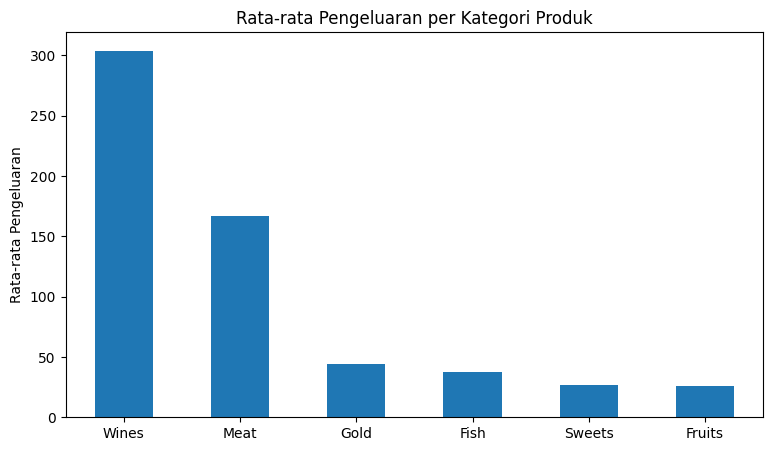

In [30]:
# Membuat visualisasi dari perhitungan rata-rata pengeluaran untuk setiap kategori produk
plt.figure(figsize=(9,5))
avg_spending.plot(kind='bar')
plt.title('Rata-rata Pengeluaran per Kategori Produk')
plt.ylabel('Rata-rata Pengeluaran')
plt.xticks(rotation=0)
plt.show()

### Interpretasi

Grafik rata-rata pengeluaran menunjukkan bahwa **Wines** memiliki rata-rata pengeluaran tertinggi, jauh di atas kategori lain, kemudian diikuti oleh **Meat**.
Artinya, saat pelanggan membeli dua kategori ini, nilai transaksi yang dihasilkan cenderung lebih besar dibanding kategori lain seperti Fruits, Fish, atau Sweets.

Implikasinya untuk bisnis adalah:
- **Wines** layak dijadikan anchor product dalam bundling karena paling kuat menaikkan nilai transaksi,
- **Meat** dapat menjadi pasangan bundling utama karena juga memiliki nilai belanja yang tinggi.

Dengan kata lain, jika perusahaan ingin meningkatkan total penjualan dari sisi nilai, bundling sebaiknya berpusat pada kategori premium yang memang paling besar nominal pembeliannya.


## 9.2 Median Pengeluaran per Kategori Produk

In [31]:
# Menghitung nilai median (nilai tengah) pengeluaran untuk setiap kategori produk
median_spending = df_products.median().sort_values(ascending=False)
median_spending

Wines    174.00
Meat      67.00
Gold      24.00
Fish      12.00
Fruits     8.00
Sweets     8.00
dtype: float64

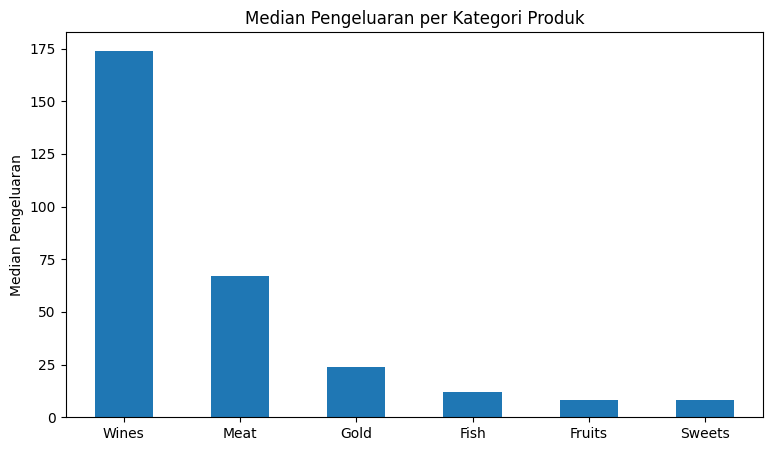

In [32]:
# Membuat visualisasi dari perhitungan median pengeluaran untuk setiap kategori produk
plt.figure(figsize=(9,5))
median_spending.plot(kind='bar')
plt.title('Median Pengeluaran per Kategori Produk')
plt.ylabel('Median Pengeluaran')
plt.xticks(rotation=0)
plt.show()

### Interpretasi

Median menunjukkan nilai belanja yang lebih mewakili pelanggan “tipikal”. Pada hasil ini, **median Wines** dan **median Meat** tetap lebih tinggi daripada kategori lain, sehingga dominasi keduanya bukan hanya karena beberapa pelanggan ekstrem saja, tetapi juga terlihat pada perilaku belanja pelanggan secara umum.

Maknanya:
- permintaan terhadap **Wines** dan **Meat** bukan sekadar kasus khusus dari sedikit pelanggan besar,
- kedua kategori ini memang relatif penting di basis pelanggan secara lebih luas.

Bagi strategi bundling, ini berarti paket yang melibatkan Wines atau Meat tidak hanya berpotensi menarik pelanggan premium, tetapi juga masih relevan bagi pelanggan tipikal dibanding paket yang hanya berisi kategori bernilai rendah.


## 9.3 Total Pengeluaran per Kategori Produk


In [33]:
# Menghitung total keseluruhan pengeluaran untuk setiap kategori produk
total_spending = df_products.sum().sort_values(ascending=False)
total_spending

Wines     680038
Meat      373393
Gold       98358
Fish       83939
Sweets     60553
Fruits     58767
dtype: int64

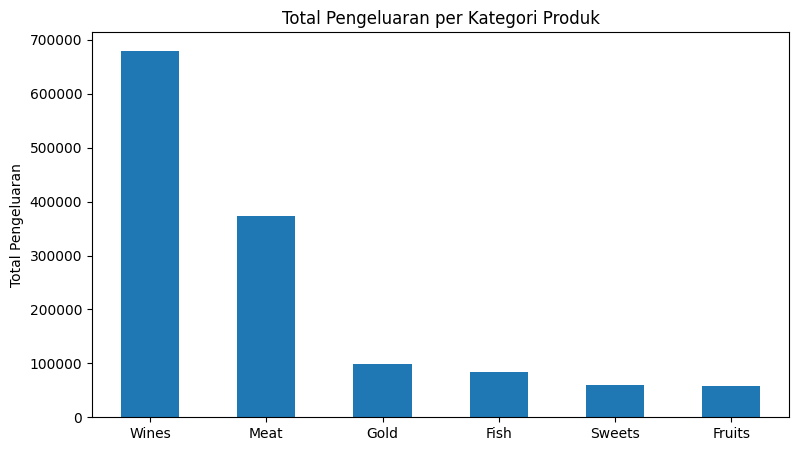

In [34]:
# Membuat visualisasi dari perhitungan total keseluruhan pengeluaran untuk setiap kategori produk
plt.figure(figsize=(9,5))
total_spending.plot(kind='bar')
plt.title('Total Pengeluaran per Kategori Produk')
plt.ylabel('Total Pengeluaran')
plt.xticks(rotation=0)
plt.show()

### Interpretasi

Total pengeluaran memperlihatkan kontribusi setiap kategori terhadap keseluruhan penjualan. Hasilnya menunjukkan bahwa **Wines** menyumbang porsi terbesar, lalu disusul **Meat** dengan selisih yang masih cukup jauh dari kategori lain.

Ini penting karena:
- jika tujuan bisnis adalah meningkatkan total penjualan, perusahaan perlu memprioritaskan kategori yang memang paling besar kontribusi nilainya,
- bundling yang melibatkan **Wines** dan **Meat** lebih berpotensi menaikkan revenue dibanding bundling antar kategori bernilai rendah.

Jadi, dari perspektif kontribusi penjualan, Wines dan Meat adalah kategori paling strategis untuk dijadikan inti promosi bundling.


## 9.4 Jumlah Pelanggan yang Membeli Setiap Kategori

In [35]:
# menghitung jumlah pelanggan yang membeli setiap kategori produk
customer_frequency = (df_products > 0).sum().sort_values(ascending=False)
customer_frequency

Meat      2236
Wines     2224
Gold      2176
Fish      1853
Fruits    1838
Sweets    1819
dtype: int64

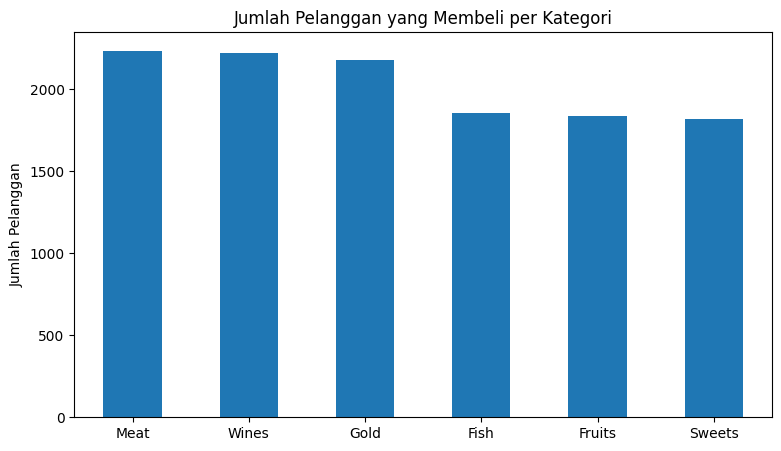

In [36]:
# Membuat visualisasi dari perhitungan jumlah pelanggan yang membeli setiap kategori produk
plt.figure(figsize=(9,5))
customer_frequency.plot(kind='bar')
plt.title('Jumlah Pelanggan yang Membeli per Kategori')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=0)
plt.show()

### Interpretasi

Grafik jumlah pelanggan pembeli menunjukkan bahwa **Meat**, **Wines**, dan **Gold** dibeli oleh paling banyak pelanggan.
Maknanya, ketiga kategori ini memiliki jangkauan pasar yang luas dan tidak terbatas hanya pada sebagian kecil pelanggan.

Untuk strategi bundling, hasil ini memberi dua arah:
- **Wines** dan **Meat** kuat dari sisi nilai sekaligus banyak dibeli, sehingga keduanya sangat ideal dijadikan komponen utama bundling,
- **Gold** menarik karena tingkat pembelinya tinggi, sehingga dapat dipertimbangkan sebagai produk pendamping dalam promosi tertentu.

Singkatnya, kategori dengan jumlah pembeli tinggi memiliki peluang penerimaan bundling yang lebih besar karena basis konsumennya sudah luas.


## 9.5 Proporsi Kontribusi Tiap Kategori terhadap Total Penjualan Produk

In [37]:
# menghitung persentase kontribusi setiap kategori produk terhadap total keseluruhan pengeluaran
share_spending = (total_spending / total_spending.sum() * 100).round(2)
share_spending

Wines    50.19
Meat     27.56
Gold      7.26
Fish      6.19
Sweets    4.47
Fruits    4.34
dtype: float64

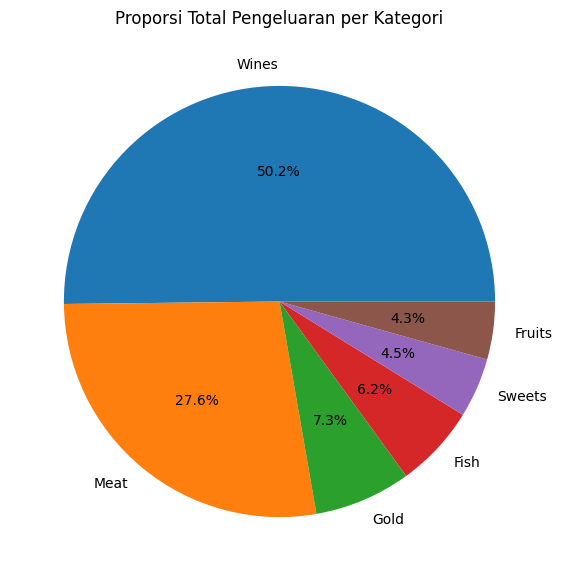

In [38]:
# Membuat visualisasi dari perhitungan persentase kontribusi setiap kategori produk terhadap total keseluruhan pengeluaran
plt.figure(figsize=(7,7))
share_spending.plot(kind='pie', autopct='%.1f%%')
plt.title('Proporsi Total Pengeluaran per Kategori')
plt.ylabel('')
plt.show()

### Interpretasi

Proporsi pengeluaran menunjukkan bahwa lebih dari setengah total belanja produk dalam data berasal dari **Wines**, sedangkan **Meat** menjadi kontributor terbesar kedua. Kategori lain menyumbang porsi yang jauh lebih kecil.

Artinya, struktur penjualan sangat ditopang oleh dua kategori utama tersebut.
Bagi bisnis, kondisi ini menunjukkan bahwa:
- peningkatan kecil pada penjualan **Wines** atau **Meat** dapat memberi dampak lebih besar ke total revenue dibanding peningkatan pada kategori kecil,
- bundling yang mendorong pembelian tambahan pada dua kategori ini akan lebih terasa pengaruhnya terhadap kinerja penjualan.

Dengan demikian, grafik ini menegaskan bahwa fokus bundling sebaiknya diarahkan ke kategori dengan porsi kontribusi terbesar.


# 10. Analisis Kecenderungan Pembelian pada Pelanggan yang Membeli Kategori Utama

Pada tahap ini dianalisis kategori lain yang juga dibeli oleh pelanggan yang membeli produk tertentu seperti Wines atau Meat. Hal ini dilakukan untuk melihat apakah terdapat kecenderungan pelanggan membeli lebih dari satu kategori, sehingga dapat digunakan sebagai dasar dalam menentukan kombinasi produk yang lebih relevan untuk bundling.

## 10.1 Menentukan Kategori Utama

Kategori utama dipilih berdasarkan gabungan pertimbangan:
- rata-rata pengeluaran,
- total pengeluaran,
- dan jumlah pelanggan pembeli.

Kategori yang kuat pada ketiga aspek tersebut paling layak dijadikan anchor product bundling.

In [39]:
# Menggabungkan hasil analisis (rata-rata, median, total, dan jumlah pembeli) ke dalam satu tabel ringkasan
summary_product = pd.DataFrame({
    'Average_Spending': avg_spending,
    'Median_Spending': median_spending,
    'Total_Spending': total_spending,
    'Customer_Buyers': customer_frequency
}).sort_values(by=['Total_Spending', 'Customer_Buyers'], ascending=False)

summary_product

,Average_Spending,Median_Spending,Total_Spending,Customer_Buyers
Wines,304.00,174.00,680038,2224
Meat,166.92,67.00,373393,2236
Gold,43.97,24.00,98358,2176
Fish,37.52,12.00,83939,1853
Sweets,27.07,8.00,60553,1819
Fruits,26.27,8.00,58767,1838


## 10.2 Kategori Lain yang Cenderung Dibeli oleh Pelanggan yang Membeli Wines

In [40]:
# Menghitung persentase pelanggan yang membeli kategori lain di antara pelanggan yang membeli Wines
wine_buyers = df_products[df_products['Wines'] > 0]
wine_tendency = (wine_buyers > 0).mean().sort_values(ascending=False) * 100
wine_tendency.round(2)

Wines    100.00
Meat     100.00
Gold      97.26
Fish      82.73
Fruits    82.28
Sweets    81.25
dtype: float64

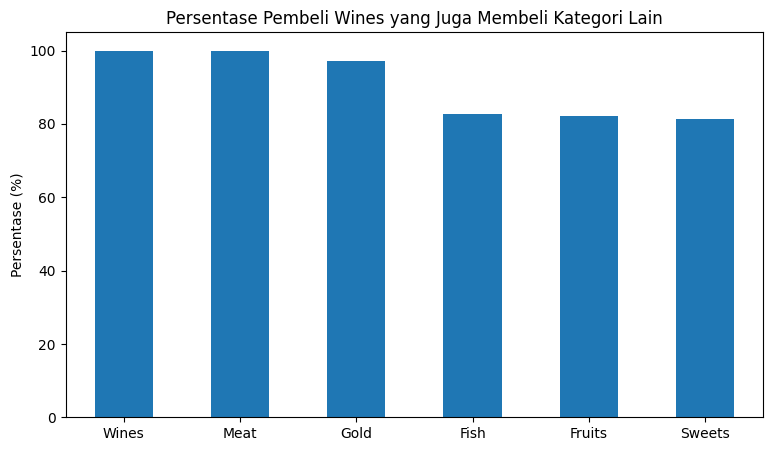

In [41]:
# Membuat hasil visualisasi dari perhitungan persentase pelanggan yang membeli kategori lain di antara pelanggan yang membeli Wines 
plt.figure(figsize=(9,5))
wine_tendency.sort_values(ascending=False).plot(kind='bar')
plt.title('Persentase Pembeli Wines yang Juga Membeli Kategori Lain')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.show()

### Interpretasi

Pada pelanggan yang membeli **Wines**, kategori yang juga paling sering ikut dibeli adalah **Meat**, **Gold**, lalu disusul kategori lain seperti **Fish**, **Fruits**, dan **Sweets** dengan persentase yang juga cukup tinggi.

Makna hasil ini adalah pembeli Wines bukan pelanggan yang hanya fokus pada satu jenis produk. Mereka cenderung memiliki pola belanja yang lebih luas dan masih membeli kategori lain dalam data.

Implikasi bisnisnya:
- **Wines + Meat** adalah kandidat bundling yang kuat karena sama-sama bernilai tinggi dan sama-sama sering muncul pada pelanggan yang sama,
- **Wines + Gold** juga bisa dipertimbangkan untuk paket yang lebih premium,
- kategori seperti **Fish** atau **Fruits** dapat dijadikan variasi bundling agar pilihan paket lebih fleksibel.

Jadi, hasil ini bukan sekadar menunjukkan definisi “cenderung dibeli”, tetapi memberi arahan konkret kategori mana yang paling masuk akal dipasangkan dengan Wines.


## 10.3 Kategori Lain yang Cenderung Dibeli oleh Pelanggan yang Membeli Meat

In [42]:
# mengambil pelanggan yang membeli Meat, lalu menghitung persentase pelanggan tersebut yang juga membeli kategori produk lain
meat_buyers = df_products[df_products['Meat'] > 0]
meat_tendency = (meat_buyers > 0).mean().sort_values(ascending=False) * 100
meat_tendency.round(2)

Meat     100.00
Wines     99.46
Gold      97.27
Fish      82.83
Fruits    82.20
Sweets    81.31
dtype: float64

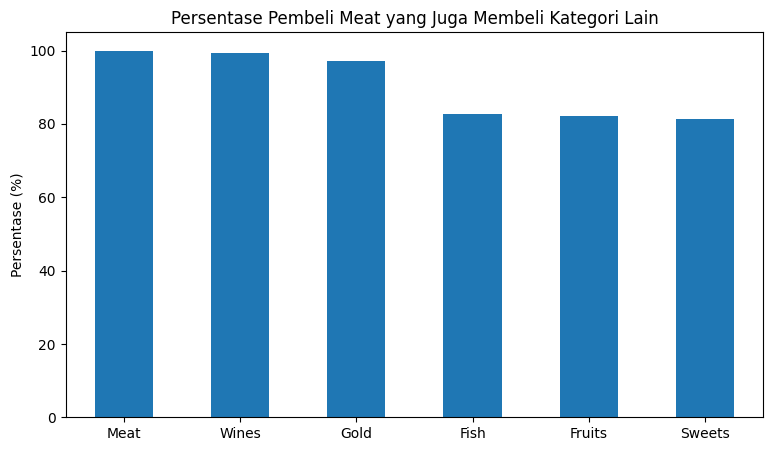

In [43]:
# Menampilkan visualisai dari perhitugan persentase pelanggan yang juga membeli kategori produk lain selain meat
plt.figure(figsize=(9,5))
meat_tendency.sort_values(ascending=False).plot(kind='bar')
plt.title('Persentase Pembeli Meat yang Juga Membeli Kategori Lain')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.show()

### Interpretasi

Pada pelanggan yang membeli **Meat**, kategori yang paling sering juga dibeli adalah **Wines**, kemudian **Gold**, diikuti **Fish**, **Fruits**, dan **Sweets**. Pola ini konsisten dengan temuan sebelumnya bahwa Meat dan Wines saling muncul kuat pada pelanggan yang sama.

Makna bisnis dari hasil ini adalah:
- **Meat** tidak berdiri sendiri sebagai kategori kebutuhan, tetapi sering muncul bersama kategori bernilai tinggi lain,
- ada peluang kuat untuk membuat paket bundling berbasis **Meat + Wines** sebagai paket utama,
- kombinasi **Meat + Fish** atau **Meat + Fruits** dapat dipakai sebagai alternatif bundling yang lebih variatif.

Dengan demikian, hasil ini memperkuat bahwa strategi bundling paling logis adalah memulai dari kategori utama lalu memasangkan dengan kategori yang memang sering muncul pada basis pelanggan yang sama.


# 11. Analisis Segmentasi Sederhana untuk Target Bundling

Pada bagian ini pelanggan dibagi ke dalam kelompok sederhana, seperti berdasarkan jumlah anak atau income, untuk melihat apakah terdapat perbedaan pola pembelian. Segmentasi ini penting karena tidak semua pelanggan memiliki kebutuhan dan daya beli yang sama, sehingga strategi bundling dapat disesuaikan agar lebih efektif dan tepat sasaran.

## 11.1 Membagi Pelanggan Berdasarkan Status Memiliki Anak

In [44]:
# Membuat kolom baru Family_Type berdasarkan jumlah anak
df_clean['Family_Type'] = np.where(df_clean['TotalChildren'] > 0, 'Dengan Anak', 'Tanpa Anak')
df_clean[['TotalChildren', 'Family_Type']].head()

,TotalChildren,Family_Type
0,0,Tanpa Anak
1,2,Dengan Anak
2,0,Tanpa Anak
3,1,Dengan Anak
4,1,Dengan Anak


In [45]:
# Menghitung rata-rata pengeluaran setiap kategori produk berdasarkan kelompok Family_Type (Dengan Anak vs Tanpa Anak)
family_product = df_clean.groupby('Family_Type')[product_cols].mean().rename(columns=product_map).T
family_product

Family_Type,Dengan Anak,Tanpa Anak
Wines,231.18,486.89
Fruits,15.94,52.21
Meat,85.14,372.31
Fish,22.00,76.50
Sweets,16.73,53.04
Gold,36.03,63.90


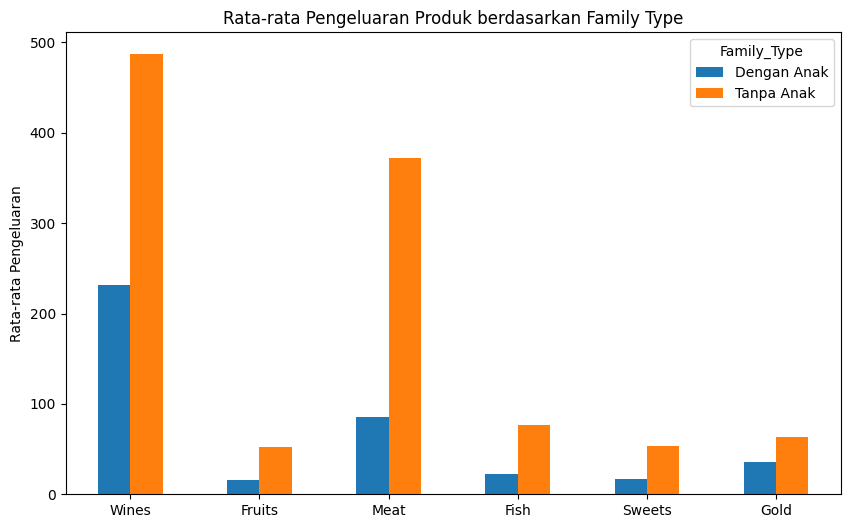

In [46]:
# Menampilkan visualisasi dari perhitugan rata-rata pengeluaran setiap kategori produk berdasarkan kelompok Family_Type (Dengan Anak vs Tanpa Anak)
family_product.plot(kind='bar', figsize=(10,6))
plt.title('Rata-rata Pengeluaran Produk berdasarkan Family Type')
plt.ylabel('Rata-rata Pengeluaran')
plt.xticks(rotation=0)
plt.show()

### Interpretasi

Grafik segmentasi menunjukkan perbedaan yang jelas antara pelanggan **Dengan Anak** dan **Tanpa Anak**. Pelanggan **Tanpa Anak** memiliki rata-rata pengeluaran yang jauh lebih tinggi di hampir semua kategori, terutama pada **Wines** dan **Meat**.

Maknanya, rumah tangga tanpa anak dalam dataset ini tampak memiliki kapasitas belanja yang lebih besar untuk produk bernilai tinggi. Sebaliknya, pelanggan dengan anak tetap membeli kategori yang sama, tetapi dengan nominal rata-rata yang lebih rendah.

Implikasi untuk strategi bundling:
- paket premium berbasis **Wines** dan **Meat** lebih cocok diarahkan ke pelanggan **Tanpa Anak**,
- pelanggan **Dengan Anak** dapat diberi bundling dengan harga lebih terjangkau atau fokus pada kombinasi yang lebih ringan.

Jadi, visualisasi ini membantu perusahaan memahami bahwa bundling tidak sebaiknya dibuat satu pola untuk semua segmen pelanggan.


# 12. Analisis Perbedaan Perilaku Pelanggan berdasarkan Income

Analisis ini melengkapi temuan deskriptif sebelumnya dengan membandingkan rata-rata pengeluaran antar kelompok income.
Tujuannya adalah melihat apakah pola belanja pelanggan berubah ketika daya beli pelanggan berbeda.


Pada tahap ini dilakukan perbandingan rata-rata pengeluaran antar kelompok pelanggan, khususnya berdasarkan income, untuk melihat apakah terdapat perbedaan perilaku pembelian. Analisis ini membantu memahami apakah strategi bundling perlu dibedakan untuk masing-masing segmen pelanggan agar hasilnya lebih optimal.

In [47]:

# Membuat kelompok Income
df_clean['Income_Group'] = pd.qcut(df_clean['Income'], q=3, labels=['Low','Medium','High'])
df_clean[['Income','Income_Group']].head()


,Income,Income_Group
0,"58,138.00",Medium
1,"46,344.00",Medium
2,"71,613.00",High
3,"26,646.00",Low
4,"58,293.00",Medium


In [48]:

# Perbandingan rata-rata pengeluaran per kategori berdasarkan Income
income_analysis = df_clean.groupby('Income_Group')[product_cols].mean().rename(columns=product_map).T
income_analysis


C:\Temp\ipykernel_40096\1639647782.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_analysis = df_clean.groupby('Income_Group')[product_cols].mean().rename(columns=product_map).T


Income_Group,Low,Medium,High
Wines,31.14,266.51,614.28
Fruits,5.99,16.54,56.26
Meat,25.69,90.57,384.39
Fish,9.06,23.64,79.85
Sweets,6.07,16.76,58.36
Gold,17.72,43.91,70.27


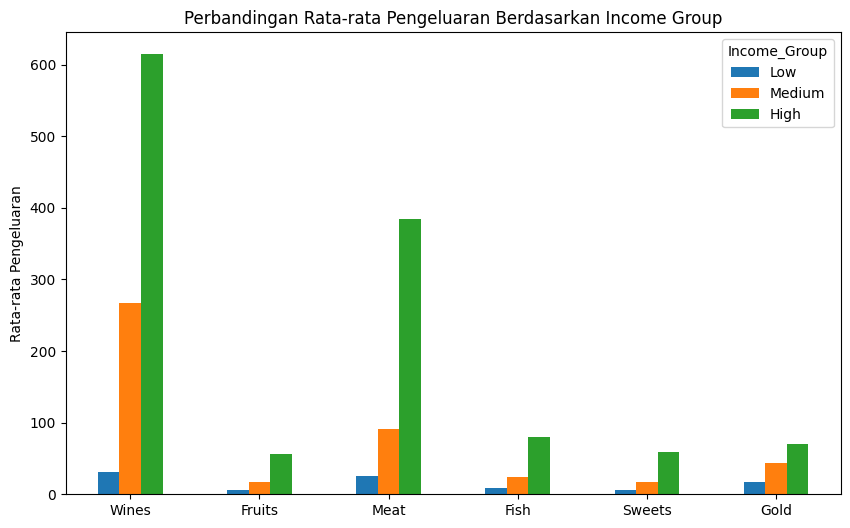

In [49]:

# Visualisasi dari perbandingan rata-rata pengeluaran per kategori berdasarkan Income
income_analysis.plot(kind='bar', figsize=(10,6))
plt.title('Perbandingan Rata-rata Pengeluaran Berdasarkan Income Group')
plt.ylabel('Rata-rata Pengeluaran')
plt.xticks(rotation=0)
plt.show()


### Interpretasi

Perbandingan antar kelompok income menunjukkan pola yang sangat jelas: semakin tinggi kelompok income, semakin tinggi pula rata-rata pengeluaran di hampir semua kategori produk. Kesenjangan paling menonjol terlihat pada **Wines** dan **Meat**.

Makna hasil ini adalah daya beli memang berhubungan langsung dengan pola belanja pelanggan:
- kelompok **High income** jauh lebih potensial untuk membeli produk premium,
- kelompok **Low income** tetap membeli kategori yang sama, tetapi dengan nilai yang jauh lebih rendah.

Implikasi bisnisnya:
- bundling premium berbasis **Wines**, **Meat**, atau kombinasi dengan **Gold** lebih tepat diarahkan ke pelanggan ber-income tinggi,
- bundling untuk kelompok income lebih rendah sebaiknya tidak terlalu berat dari sisi harga agar tetap relevan.

Dengan demikian, hasil ini membantu perusahaan menyusun strategi bundling yang tidak hanya berdasarkan produk, tetapi juga berdasarkan kemampuan belanja pelanggan.


## Insight Utama 
Berdasarkan hasil analisis pada poin 9–12, diperoleh kesimpulan utama sebagai berikut:

1. Kategori bernilai tinggi seperti Wines dan Meat merupakan kontributor utama revenue dan layak dijadikan anchor product.
2. Kategori dengan jumlah pembeli tinggi cocok sebagai pendamping bundling karena lebih mudah diterima pelanggan.
3. Terdapat kecenderungan pelanggan membeli lebih dari satu kategori, membuka peluang cross-selling.
4. Perbedaan perilaku berdasarkan income dan kondisi keluarga menunjukkan pentingnya segmentasi.

Kesimpulan: bundling yang efektif harus menggabungkan nilai produk, frekuensi pembelian, dan karakteristik pelanggan.


# 13. Rekomendasi 

Berikut rekomendasi yang dapat diberikan kepada perusahaan berdasarkan hasil analisis:

1. Jadikan Wines sebagai anchor product utama
Wines memiliki kontribusi nilai penjualan terbesar dalam data. Karena itu, bundling yang berpusat pada Wines berpotensi memberi dampak paling besar terhadap kenaikan total penjualan.

2. Gunakan Meat sebagai pasangan bundling utama
Meat konsisten tinggi dari sisi rata-rata, total, dan kecenderungan dibeli oleh pembeli Wines. Paket **Wines + Meat** menjadi rekomendasi paling kuat karena menggabungkan dua kategori bernilai tinggi sekaligus.

3. Siapkan opsi bundling premium dan bundling alternatif
Selain paket utama **Wines + Meat**, perusahaan juga dapat menyiapkan:
- **Wines + Gold** untuk penawaran yang lebih premium,
- **Meat + Fish** atau **Meat + Fruits** untuk variasi paket yang lebih fleksibel.

4. Sesuaikan bundling dengan segmen pelanggan
Pelanggan **Tanpa Anak** dan **High income** lebih cocok menerima paket premium karena nominal belanjanya lebih tinggi.
Sebaliknya, segmen dengan daya beli lebih rendah lebih cocok ditawari paket yang lebih sederhana agar peluang konversinya tetap baik.

5. Fokus pada peningkatan nilai transaksi dan profitabilitas
Bundling yang baik tidak hanya menambah jumlah item terjual, tetapi juga mendorong pelanggan membeli kategori bernilai tinggi dalam satu pembelian. Karena itu, strategi bundling yang melibatkan Wines dan Meat lebih berpotensi meningkatkan total penjualan sekaligus profitabilitas dibanding paket yang hanya berisi kategori kecil.


Pada tahap ini disusun rekomendasi strategi bundling berdasarkan hasil analisis sebelumnya, dengan fokus pada kombinasi produk yang bernilai tinggi dan sering dibeli, serta mempertimbangkan perbedaan karakteristik pelanggan agar dapat meningkatkan penjualan dan potensi profitabilitas.

# 14. Kesimpulan

Dari analisis yang dilakukan, dapat disimpulkan bahwa:

Berdasarkan hasil analisis, kategori Wines dan Meat merupakan produk dengan kontribusi terbesar terhadap penjualan, baik dari sisi nilai maupun jumlah pelanggan, sehingga sangat potensial dijadikan sebagai dasar strategi bundling. Pelanggan juga menunjukkan kecenderungan membeli lebih dari satu kategori produk, yang membuka peluang untuk strategi cross-selling melalui bundling yang relevan.

Selain itu, perbedaan karakteristik pelanggan, khususnya berdasarkan income dan kondisi keluarga, menunjukkan bahwa strategi bundling perlu disesuaikan dengan segmen pelanggan agar lebih efektif. Dengan menggabungkan produk bernilai tinggi dan produk yang sering dibeli, perusahaan dapat meningkatkan nilai transaksi per pelanggan.
